/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

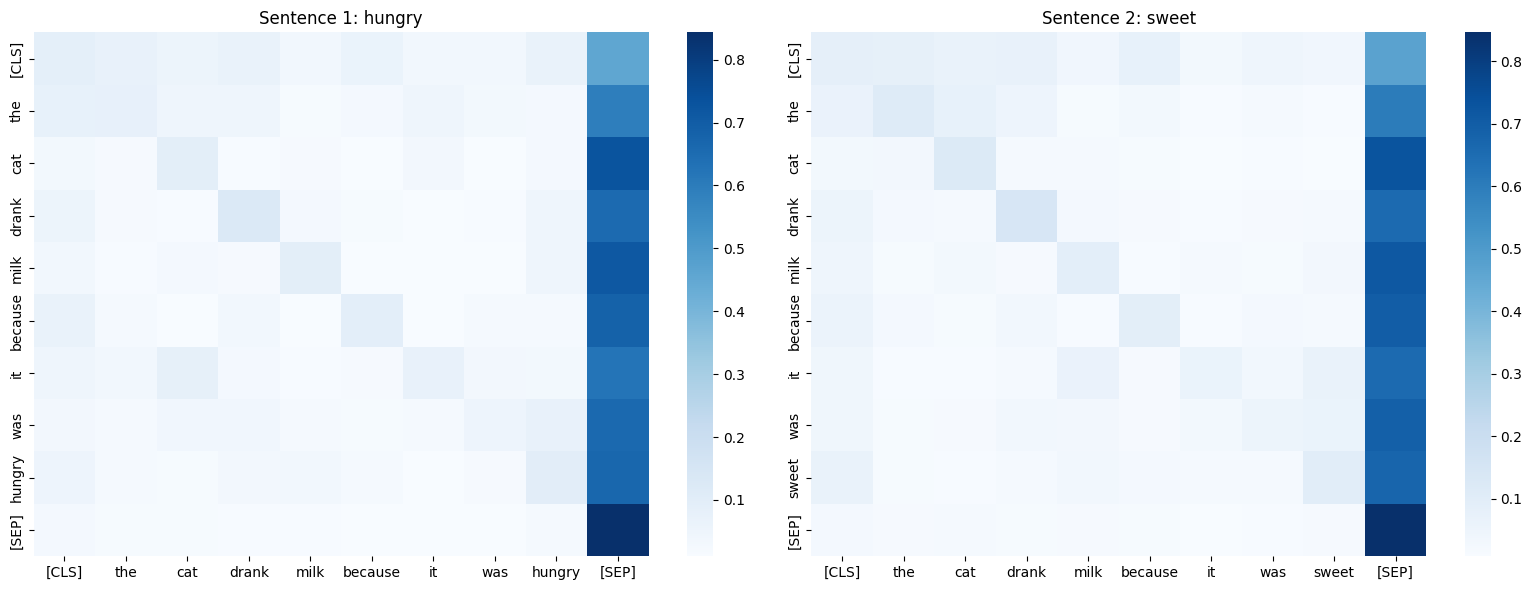


Attention values for Sentence 1 (hungry):
  it → cat  : 0.0848
  it → milk : 0.0145

Attention values for Sentence 2 (sweet):
  it → cat  : 0.0137
  it → milk : 0.0640


In [1]:
import torch
from transformers import BertTokenizer, BertModel
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load pretrained BERT with attention outputs
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)

# 2. Define two sentences
sentence1 = "The cat drank milk because it was hungry"
sentence2 = "The cat drank milk because it was sweet"
sentences = [sentence1, sentence2]

def get_avg_attention(sentence):
    # Tokenize
    inputs = tokenizer(sentence, return_tensors="pt")
    # Forward pass
    outputs = model(**inputs)
    attentions = outputs.attentions  # list of [batch, heads, seq_len, seq_len]

    # Select the two layers before the last one
    last_two = attentions[-2:]  # e.g., layers 10 and 11 in a 12-layer model

    # Average across heads and across these two layers
    avg_attention = torch.stack([layer.mean(dim=1) for layer in last_two])  # [2, batch, seq_len, seq_len]
    avg_attention = avg_attention.mean(dim=0)[0]  # [seq_len, seq_len]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    return avg_attention.detach().numpy(), tokens

# 3. Compute attention for both sentences
att1, tokens1 = get_avg_attention(sentence1)
att2, tokens2 = get_avg_attention(sentence2)

# 4. Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(att1, xticklabels=tokens1, yticklabels=tokens1, cmap="Blues", ax=axes[0])
axes[0].set_title("Sentence 1: hungry")

sns.heatmap(att2, xticklabels=tokens2, yticklabels=tokens2, cmap="Blues", ax=axes[1])
axes[1].set_title("Sentence 2: sweet")

plt.tight_layout()
plt.show()

# 5. Print specific attention values
def print_attention_values(att, tokens, sentence_label):
    try:
        idx_it = tokens.index("it")
        idx_cat = tokens.index("cat")
        idx_milk = tokens.index("milk")
    except ValueError:
        print(f"Tokens not found in {sentence_label}: {tokens}")
        return

    print(f"\nAttention values for {sentence_label}:")
    print(f"  it → cat  : {att[idx_it, idx_cat]:.4f}")
    print(f"  it → milk : {att[idx_it, idx_milk]:.4f}")

print_attention_values(att1, tokens1, "Sentence 1 (hungry)")
print_attention_values(att2, tokens2, "Sentence 2 (sweet)")
